<a href="https://colab.research.google.com/github/sinJiNi1001/Pest-Identification/blob/main/Pestornot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 309 files belonging to 2 classes.
Using 248 files for training.
Found 309 files belonging to 2 classes.
Using 61 files for validation.
Detected classes: ['Non-pest', 'Pest']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Training...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 102s 10s/step - accuracy: 0.4553 - loss: 0.8336 - val_accuracy: 0.7541 - val_loss: 0.5117
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 468ms/step - accuracy: 0.7220 - loss: 0.5475 - val_accuracy: 0.8361 - val_loss: 0.3707
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 523ms/step - accuracy: 0.8742 - loss: 0.3680 - val_accuracy: 0.9180 - val_loss: 0.2901
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 383ms/step - accuracy: 0.9189 - loss: 0.2986 - val_accuracy: 0.8852 - val_loss: 0.2377
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.9486 - loss: 0.2163 - val_accuracy: 0.9180 - val_loss: 0.2068
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 623ms/step - accuracy: 0.9679 - loss: 0.1971 - val_accuracy: 0.9508 - val_loss: 0.1849
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 374ms/step - accuracy: 0.9768 - loss: 0.1689 - val_accuracy: 0.9508 - val_loss: 0.1706
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.9772 - loss: 0.1424 - val_accuracy: 0.9508 - val_loss: 0.1605
Epo

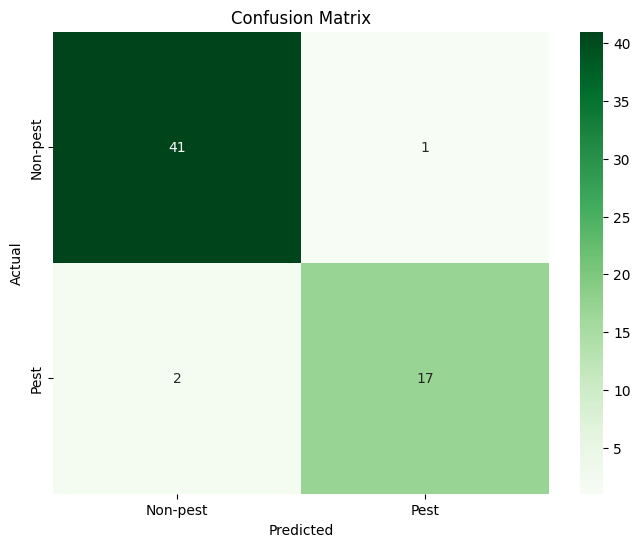

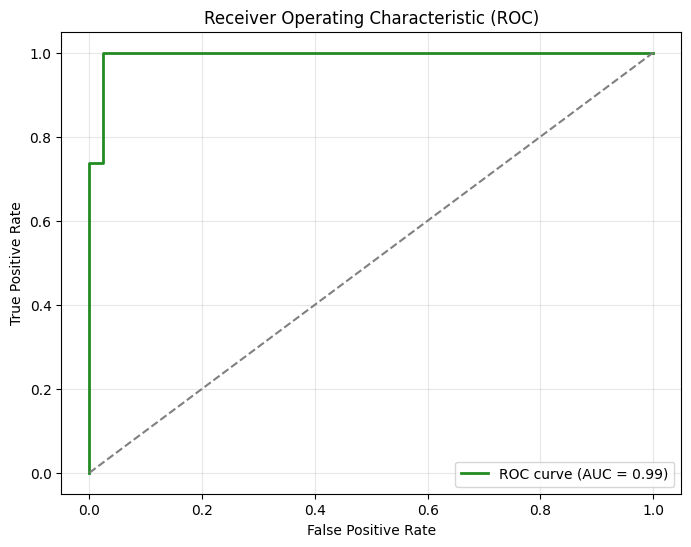

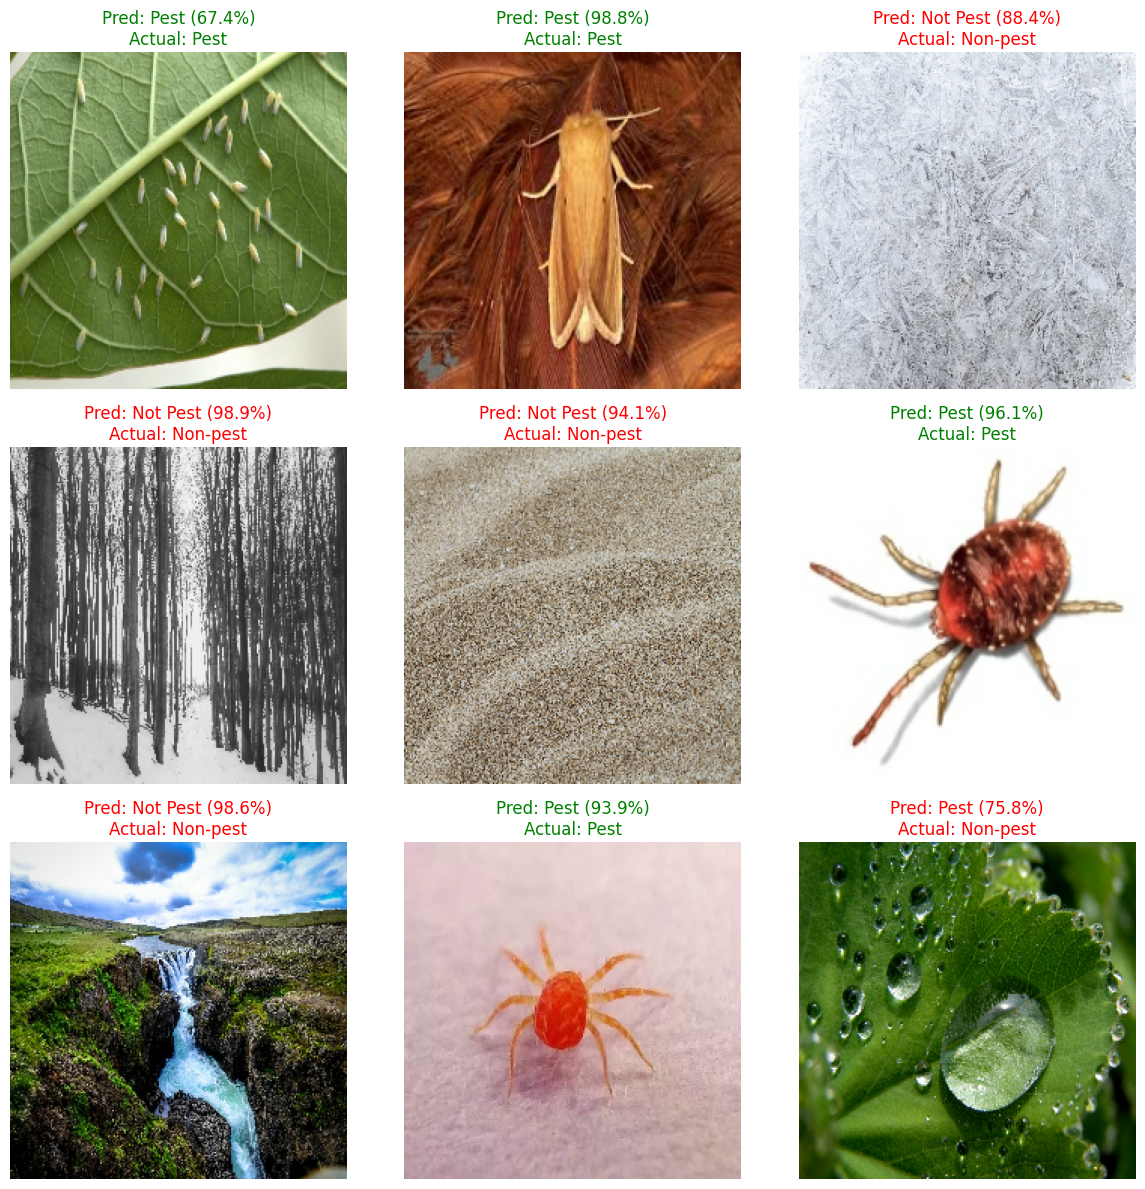

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import drive, files

# --- 1. MOUNT GOOGLE DRIVE ---
drive.mount('/content/drive')

# --- 2. SETTINGS ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# Based on your Drive structure:
DATA_DIR = '/content/drive/MyDrive/PestOrNot'

# --- 3. LOAD DATA ---
# This will automatically pick up "Pest" and "Not_Pest" folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names # Expected: ['Not_Pest', 'Pest']
print(f"Detected classes: {class_names}")

# --- 4. MODEL BUILDING ---
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 5. TRAINING ---
print("\nStarting Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# --- 6. EVALUATION ---
y_true = []
y_pred_probs = []

# Iterate through validation set to get all labels and predictions
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(int)

# Classification Metrics
print("\n--- Detailed Metrics ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC Plot
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# --- 7. VISUALIZE PREDICTIONS ---
plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # Convert back to uint8 for display since we rescaled in the model
        plt.imshow(images[i].numpy().astype("uint8"))

        prob = preds[i][0]
        # Logic for Pest/Not Pest
        label_str = "Pest" if prob > 0.5 else "Not Pest"
        confidence = prob if prob > 0.5 else 1 - prob

        # Color code: Green if correct, Red if wrong
        true_label_str = class_names[labels[i]]
        color = 'green' if label_str == true_label_str else 'red'

        plt.title(f"Pred: {label_str} ({confidence:.1%})\nActual: {true_label_str}", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()

# --- 8. SAVE & DOWNLOAD .PKL ---
# Saving the weights and architecture to a pickle file
model_data = {
    'weights': model.get_weights(),
    'config': model.get_config(),
    'classes': class_names
}

with open('pest_detector_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\nDownloading the .pkl file...")
files.download('pest_detector_model.pkl')